In [11]:
import os

from ipywidgets import interact
import ipywidgets as widgets

import mlflow

import re

import torch
from model import DelphiConfig, Delphi
from utils import get_p2i, get_batch
from tqdm import tqdm
import pandas as pd
import numpy as np
import textwrap
import matplotlib.pyplot as plt

from easydict import EasyDict
import ast
import torch.nn.functional as F

In [12]:
device = 'cpu'
dtype = getattr(torch, 'float32')

seed = 1337
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

In [13]:
def get_val_data(val_filename):
    val_data = np.memmap(val_filename, dtype=np.int32).reshape(-1, 3)
    val_p2i = get_p2i(val_data)
    return val_data, val_p2i

In [14]:
runs_df = mlflow.search_runs(experiment_ids = [exp.experiment_id for exp in mlflow.search_experiments()])
runs_df = runs_df[runs_df['params.fold'].notnull()]

grouped = runs_df.groupby('experiment_id')

exp_ids = []

for exp_id, group in grouped:
    
    if group['params.fold'].nunique() == 5:
        # print(group[['run_id', 'params.val_filename']])
        print(f"Experiment ID: {exp_id}")
        exp_ids.append(exp_id)

runs_df = runs_df[runs_df['experiment_id'].isin(exp_ids)]
runinfo = runs_df.iloc[0]

Experiment ID: 142875796809514624
Experiment ID: 278131880607437980
Experiment ID: 437945341875567335


In [15]:
val_data, val_p2i = get_val_data(val_filename=runinfo['params.val_filename'])

assert os.path.exists(ckpt_dir := re.sub(pattern='.*/mlruns', repl='mlruns', string=runinfo.artifact_uri)), f"{ckpt_path} does not exist"

ckpt_dir = ckpt_dir + "/" + "checkpoints"

def get_epoch_from_ckpt(ckpt_path):
    return int(ckpt_path.split("_")[-1].split(".")[0])

best_ckpt_path = ckpt_dir + '/' + sorted(os.listdir(ckpt_dir), key=get_epoch_from_ckpt)[-1]
model = Delphi.from_checkpoint(best_ckpt_path)
model = model.eval()

number of parameters: 1.21M


In [16]:
NO_EVENT_TOKEN_ID = 1

In [17]:
ignored_tokens = ast.literal_eval(runinfo['params.ignore_tokens'])

validation_loss_mode = True
if validation_loss_mode:
    ignored_tokens += [NO_EVENT_TOKEN_ID]    

ignored_tokens_set = set(ignored_tokens)

In [32]:
labels = pd.read_csv("delphi_labels_chapters_colours_icd.csv")

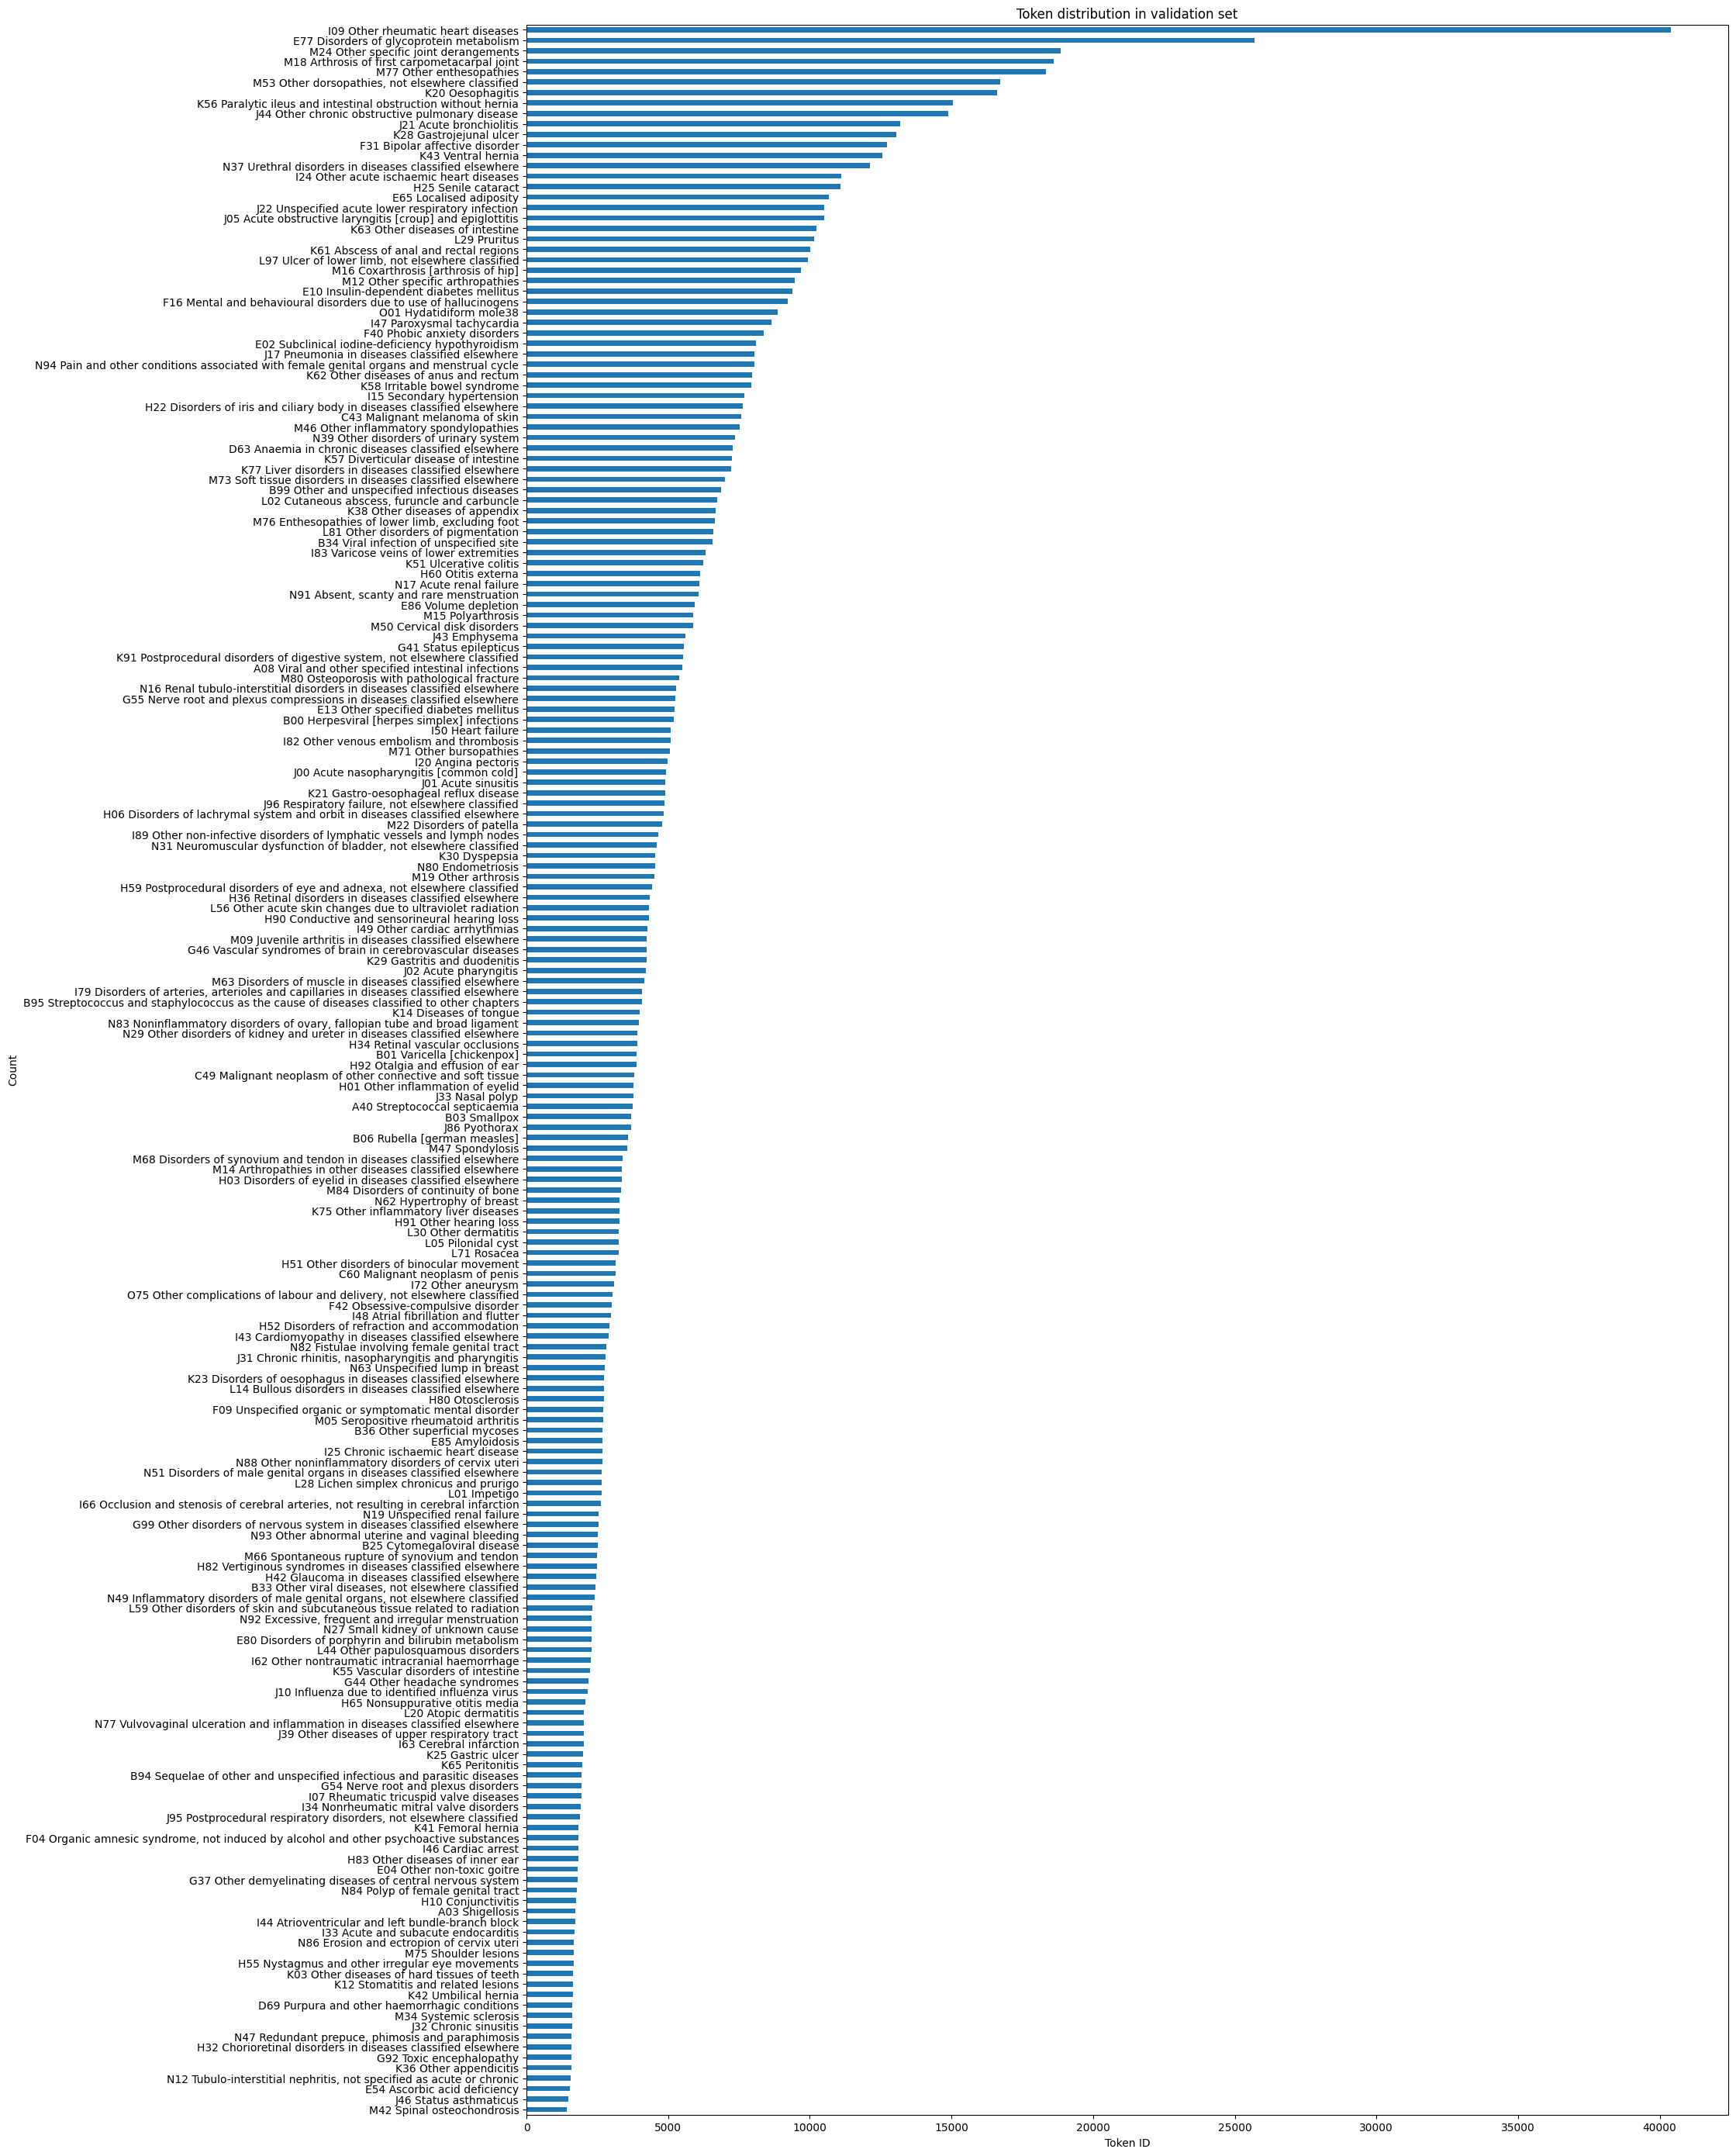

In [51]:
id_to_token = dict(zip(labels.index, labels.name))

pd.DataFrame(val_data, columns=["subject_id", "age", "token_id"]).\
    query("token_id not in @ignored_tokens").\
    assign(token=lambda df: df.token_id.apply(lambda x: id_to_token[x])).\
    token.value_counts(ascending=False).\
    head(200).\
    sort_values().\
    plot(kind='barh', figsize=(20, 35), title="Token distribution in validation set", xlabel="Token ID", ylabel="Count");

In [ ]:
import concurrent.futures

BLOCK_SIZE = 96

def get_batch_wrapper(idx):
    return get_batch(ix=idx, data=val_data, p2i=val_p2i, select='left', block_size=BLOCK_SIZE, device=device, padding='random')

mini_batch_size = 32
N_CHUNKS = 16

ix = torch.randint(len(val_p2i), (batch_size := N_CHUNKS*mini_batch_size,))

with concurrent.futures.ThreadPoolExecutor() as executor:
    batches = list(executor.map(get_batch_wrapper, ix.chunk(N_CHUNKS)))

d = EasyDict({
    "X": torch.stack([b[0] for b in batches]),
    "age_X": torch.stack([b[1] for b in batches]),
    "Y": torch.stack([b[2] for b in batches]),
    "age_Y": torch.stack([b[3] for b in batches])
})

idx = d.X.reshape(-1, d.X.size(-1))
age = d.age_X.reshape(-1, d.X.size(-1))
targets = d.Y.reshape(-1, d.Y.size(-1))
targets_age = d.age_Y.reshape(-1, d.Y.size(-1))

def model_forward(X, age_X):
    with torch.no_grad():
        return model(X, age_X)

with concurrent.futures.ThreadPoolExecutor() as executor:
    outputs = list(executor.map(lambda b: model(b[0], b[1]), batches))

In [ ]:
logits = torch.concat([ outputs[b][0] for b in range(len(outputs)) ])

In [ ]:
t_min = runinfo['params.t_min']# = runinfo['params.t_min'] if 'params.t_min' in runinfo else 0.0
t_min = float(t_min)

In [ ]:
mask_ties = ast.literal_eval(runinfo['params.mask_ties'])

In [ ]:
tokens_of_interest = [ x for x in range(len(labels)) if x not in ignored_tokens_set ]

In [ ]:
attn_mask = (idx>0).view(idx.size(0), 1, 1, idx.size(1)) * (idx>0).view(idx.size(0),1,idx.size(1),1)  # Do not attend to padded positions
attn_mask *= torch.tril(torch.ones(idx.size(1),idx.size(1), device=device))[None,None,:,:] > 0 #self.transformer.h[0].attn.bias[:,:,:idx.size(1),:idx.size(1)] > 0

if targets is not None and mask_ties:
    attn_mask *= ((age.view(idx.size(0),1,1,idx.size(1)) != targets_age.view(idx.size(0),1,idx.size(1),1))) # Mask co-occuring tokens
    attn_mask += (attn_mask.sum(-1, keepdim=True)==0) * torch.diag(torch.ones(idx.size(1), device=device)) > 0

attn_mask = attn_mask + (idx==0).view(idx.size(0), 1, 1, idx.size(1)) * torch.diag(torch.ones(idx.size(1), device=device)) > 0 # Except for padding
attn_mask *= torch.tril(torch.ones(idx.size(1),idx.size(1), device=device))[None,None,:,:] > 0 #self.transformer.h[0].attn.bias[:,:,:idx.size(1),:idx.size(1)] > 0

In [ ]:
with torch.no_grad():

    # if we are given some desired targets also calculate the loss
    # ignored_tokens = self.config.ignore_tokens.copy()    
    
    if validation_loss_mode:
        logits[...,ignored_tokens] = -torch.inf

    targets = targets.reshape(-1)
    pass_tokens = targets != -1 
    for k in ignored_tokens: # and gender
        pass_tokens *= targets != k
    
    #age_min = age.gather(1,(((idx >=4) * (idx <=12)) + 0).argmax(1)[:,None])
    #logits[...,-1][age <= age_min] = -100. #-float('Inf') ## Death can only occur after age_min
    
    loss_ce = F.cross_entropy(logits.reshape(-1, logits.size(-1))[pass_tokens], targets[pass_tokens], ignore_index=-1)
    
    # time to next event loss, padding masked
    lse = torch.logsumexp(logits,-1) ## More forgiving than using torch.max() for the most likely next event
    lse = - torch.log(torch.exp(-lse) + t_min)
    dt = torch.clamp(targets_age - age, min=1.0)
    if mask_ties:
        dt = torch.gather(dt, -1, (attn_mask * torch.arange(0, idx.size(1), device=device, dtype=torch.float32)
                                   .view(1, 1, 1, -1)).max(-1).indices.squeeze((1, 2)))  # Use time from last untied token
    ldt = - torch.log(dt + t_min).view(-1)
    
    loss_dt = -(lse.reshape(-1) - torch.exp(lse.reshape(-1) - ldt.reshape(-1))) ## Exponential log-likelihood (real statistics, TM)
    loss_dt = torch.mean(loss_dt[pass_tokens]) 
    
    # Both losses combined
    # loss = loss_ce + loss_dt
    loss = {'loss_ce': loss_ce, 'loss_dt': loss_dt}

In [ ]:
loss = EasyDict()
with torch.no_grad():
    for allowed_token in tqdm(tokens_of_interest):
        targets = targets.reshape(-1)
        pass_tokens = targets != -1
        pass_tokens *= targets == allowed_token
        if pass_tokens.sum() > 0:
            loss[f'loss_ce_{allowed_token}'] += F.cross_entropy(logits.reshape(-1, logits.size(-1))[pass_tokens], targets[pass_tokens], ignore_index=-1)
        # loss[f'loss_dt_{allowed_token}'] = - torch.log(torch.clamp(targets_age - age, min=1.0) + t_min).mean()

In [ ]:
loss

In [ ]:
pass_tokens

In [ ]:
loss_ce = F.cross_entropy(logits.reshape(-1, logits.size(-1))[pass_tokens], targets[pass_tokens], ignore_index=-1)
loss_ce

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
output[2].transpose(SAMPLE_IDX:=0, LAYER_IDX:=1).shape
SAMPLE_IDX, LAYER_IDX = LAYER_IDX, SAMPLE_IDX